# Goals

### Plot 1. Tune scan
•	D term / B term (Q) (show the best tune for our MD around 24)

•	$∆\phi (Q)$

•	$X_col (Q)$ (projection of center of the crystal on the collimators, no kick, error bars show projections of the inner and outer parts of the crystal)

•	$∆Xcol (Q) = \sqrt(\beta_col \beta_cry) sin(∆\phi) x’_cry  $
 
### Table 1. Q22 optics summary (list of bullet points)
•	Qx =?, Qy=?

•	$∆\phi$ TECA->TCSM, ∆\phi TECA->TPST, ∆\phi TCSM->TPST

•	D term / B term (at TECA, TCSM and TPST)

•	$\sigma_x max$,  $\sigma_y max$
 
### Table 2. Summary for two chosen working points (Just list of bullet points for each of chosen tunes)
•	Qx =?, Qy=? (write down numbers)

•	$∆\phi$ TECA->TCSM, ∆\phi TECA->TPST, ∆\phi TCSM->TPST

•	D term / B term (at TECA, TCSM and TPST)

•	$\sigma_x max$ , $\sigma_y max $



In [111]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing libraries and computing fixed quantities

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [113]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


In [114]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [115]:
EX = N_EX / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [116]:
deltaP_P = 1e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.001


In [117]:
# TECA DEFINITION

TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = - 52.4e-3,
    tilt = - 1.23e-3,
    width = 1.8e-3,
    height = 50e-3
    )

# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle 

In [118]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # lose the particles on the blade
        particles.state[:n_part] = np.where((particles.x[:n_part]>self.blade_position) & (particles.x[:n_part]<(self.blade_position+self.thickness)) & (particles.state[:n_part]==1), -1, 1)

        # kick the particles beyond the blade
        if self.kick != 0:
            particles.px[:n_part] +=  np.where((particles.x[:n_part] > (self.blade_position+self.thickness)) & (particles.state[:n_part]==1), 1, 0) * self.kick

        return None


In [119]:
# install the 5 zs
def install_septa(line, install_zs=True, septum_aperture_size=68e-3):#
    septa_names_with_apertures = []

    if install_zs:
        septum_names = ["zs.21633", "zs.21639", "zs.21655", "zs.21671", "zs.21676"]
        
        for septum_name in septum_names:
            zs = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=septum_aperture_size, thickness=0.3e-3, kick=0.440e-3 / 5
                ),
            )
            line.insert_element(septum_name + ".sep", zs, index=septum_name)
            septa_names_with_apertures.append(septum_name + ".sep")

        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=0
            ),
        )
        line.insert_element("tpst.21760_entry" + ".sep", zs, index="tpst.21760_entry")
        septa_names_with_apertures.append("tpst.21760_entry" + ".sep")


    for mst in ["mst.21774", "mst.21779", "mst.21794"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=1.69520713e-3 / 3
            ),
        )
        line.insert_element(mst + ".sep", zs, index=mst)
        septa_names_with_apertures.append(mst + ".sep")

    for mse in ["mse.21832", "mse.21837", "mse.21852", "mse.21857", "mse.21872"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=20e-3, kick=9.74519477e-3 / 5
            ),
        )
        line.insert_element(mse + ".sep", zs, index=mse)
        septa_names_with_apertures.append(mse + ".sep")

    septum = xt.LimitRect(min_x=-1.0, max_x=septum_aperture_size, min_y=-1.0, max_y=1.0)


    line.insert_element(
        name="tt20.extraction",
        element=xt.LimitRect(min_x=-1.0, max_x=70e-3, min_y=-1.0, max_y=1.0),
        index="ap.do.mse21872",
    )
    return septa_names_with_apertures


# Uploading the sequence

In [120]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']


septa_names_with_apertures = install_septa(line, install_zs=True)
line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 4795858064>

In [121]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
22.13000000010263
22.180000000010537


In [122]:
#COMPUTING THE TWISS PARAMETERS AT THE TECA LOCATION TO COMPARE THE TUNES
    
tw_init = tw_init.to_pandas()
tw_init.index = tw_init.name   
    
max_betx = tw_init['betx'].max()
min_betx = tw_init['betx'].min()

# DISPERSION ALONG THE RING
max_dx = tw_init['dx'].max()
min_dx = tw_init['dx'].min()

# DISPERSION AND BETX AT THE TECA LOCATION
beta_x_at_teca = tw_init.loc['TECA.entry'].betx
dx_at_teca = tw_init.loc['TECA.entry'].dx
    
EpsilonBeta = beta_x_at_teca * EX

D_xDeltaP = (dx_at_teca * deltaP_P)*(dx_at_teca * deltaP_P)
sigma_xMAXinit =  np.sqrt(max_betx * EX + max_dx * deltaP_P * max_dx * deltaP_P)

print(f"sigma_xMAX: {sigma_xMAXinit}")


sigma_xMAX: 0.007074985086550772


In [123]:
# Compute sigma_yMAX
max_bety = tw_init['bety'].max()

# Assuming vertical emittance EY is similar to EX
EY = N_EY / gamma

# Compute max_dy and beta_y_at_teca
max_dy = tw_init['dy'].max()


sigma_yMAX = np.sqrt(max_bety * EY + max_dy * deltaP_P * max_dy * deltaP_P)
print(f"sigma_yMAX: {sigma_yMAX}")

sigma_yMAX: 0.0011036200168346405


In [124]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']


# Tweaking tunes 15 to 26 for the tunes

In [125]:
# Define the range of tunes to inspect, avoiding integers and half-integers
#tune_range = [x / 10 for x in range(150, 270) if x % 10 != 0 and x % 10 != 5]   # from 15.0 to 25.9 for all decimals less than integers and half inegers
tune_range = [x / 10 for x in range(150, 270)]   # from 15.0 to 25.9 for all decimals

# Initialize an empty DataFrame to store Twiss parameters
twiss_df = pd.DataFrame()

In [126]:
len(tune_range)

120

In [127]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),    # Desired target tunes
        ])
    return opt

In [128]:
def compute_x_channeledTPST_positive(beta_tpst, beta_x_at_teca, delta_mu_xtpst, E, dEX, TECA_jaw, dx_at_teca, deltaP_P, dispersion_tpst):
    return np.sqrt(beta_tpst / beta_x_at_teca) * (
        np.cos(delta_mu_xtpst) + 
        np.sqrt((beta_x_at_teca * (E + dEX)) / ((TECA_jaw - dx_at_teca * deltaP_P) * (TECA_jaw - dx_at_teca * deltaP_P)) - 1) * 
        np.sin(delta_mu_xtpst)
    ) * (TECA_jaw - dx_at_teca * deltaP_P) + dispersion_tpst * deltaP_P



In [129]:
# Loop over the range of tunes
for tune in tune_range:
    
    
    # Set up the matching process with the current target tunes
    if tune % 1 == 0 or tune % 0.5 == 0:
        opt = match_tunes(line, tune + 0.08, tune + 0.06)
    else:
        opt = match_tunes(line, tune, tune + 0.05)
    
    
    #opt = match_tunes(line, tune, tune + 0.05)
    opt.step(10)
    
    opt.target_status()
    opt.vary_status()    

    # Recalculate the Twiss parameters after setting the tunes
    tw = line.twiss(method='4d')
    tw = tw.to_pandas()
    
    tw.index = tw.name
    
    # COMPUTING

    # MAX BETAX ALONG THE RING
    max_betx = tw['betx'].max()
    min_betx = tw['betx'].min()
    # MAX DISPERSION ALONG THE RING
    max_dx = tw['dx'].max()
    min_dx = tw['dx'].min()
    # BIGGEST SIGMA_X ALONG THE RING
    sigma_xMAX =  np.sqrt(max_betx * EX + max_dx * deltaP_P * max_dx * deltaP_P)
    
    
    
                                                                # TECA
    ######################################################################
    #BETAX AND DISPERION AT TECA
    beta_x_at_teca = tw.loc['TECA.entry'].betx
    alpha_teca = tw.loc['TECA.entry'].alfx                 #ALPHA X AT TECA
    gamma_teca = (1 + alpha_teca**2) / beta_x_at_teca
    
    dx_at_teca = tw.loc['TECA.entry'].dx        #DISPERSION AT TECA
    dpx_teca = tw.loc['TECA.entry'].dpx                    #D' X AT TECA
    
    # BETATRON AND DISPERSION TERMS AT TECA
    EpsilonBetaTeca = beta_x_at_teca * EX
    D_xDeltaPTeca = (dx_at_teca * deltaP_P)*(dx_at_teca * deltaP_P)
    
                                                                    # TPST twiss parameters
    ######################################################################
    beta_tpst = tw.loc['tpst.21760_entry'].betx
    dispersion_tpst = tw.loc['tpst.21760_entry'].dx
    EpsilonBetaTPST = beta_tpst * EX
    D_xDeltaPTPST = (dispersion_tpst * deltaP_P)*(dispersion_tpst * deltaP_P)
    
                                                                    # TCSM twiss parameters
    ######################################################################
    beta_tcsm = tw.loc['tcsm.51932.'].betx
    dispersion_tcsm = tw.loc['tcsm.51932.'].dx
    
    EpsilonBetaTCSM = beta_tcsm * EX
    D_xDeltaPTCSM = (dispersion_tcsm * deltaP_P)*(dispersion_tcsm * deltaP_P)
    
    
    ######################################################################## PHASE ADVANCE STUDIES
    # Get the phase advances at the positions of the TECA and TPST markers
    mu_x_teca = tw.loc['TECA.entry'].mux
    mu_x_tpst = tw.loc['tpst.21760_entry'].mux
    mu_x_tcsm = tw.loc['tcsm.51932.'].mux

    # Calculate the phase advance between the TECA and TPST markers
    delta_mu_xtpst = (mu_x_tpst - mu_x_teca) * 2 * np.pi
    # Calculate the phase advance between the TECA and TCMS markers
    delta_mu_x_tcsm = (mu_x_tcsm - mu_x_teca) * 2 * np.pi
    # Calculate the phase advance between the TPST and TCMS markers
    delta_mu_TCSM_TPST = (mu_x_tcsm - mu_x_tpst) * 2 * np.pi
    
                                                                    # x AT TPST 
    #####################################################################
    x_NONchanneledTPST = np.sqrt(beta_tpst/beta_x_at_teca)*(np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.jaw + TECA.width) + np.sqrt(beta_tpst*beta_x_at_teca) *  np.sin(delta_mu_xtpst) * TECA.tilt

                                                                    # x AT TCSM 
    #####################################################################
    x_NONchanneledTCSM = np.sqrt(delta_mu_x_tcsm/beta_x_at_teca)*(np.cos(delta_mu_x_tcsm) + alpha_teca * np.sin(delta_mu_x_tcsm)) * (TECA.jaw + TECA.width) + np.sqrt(beta_tpst*beta_x_at_teca) *  np.sin(delta_mu_x_tcsm) * TECA.tilt
    
    
                                                                            # DIFFERENCE BETWEEN CHANNELED AND NON CHANNELED PARTICLES POSITION AT THE COLLIMATORS Computing the \delta_x at the TECA and TCMS taking only into account the channeling effect 
    #####################################################################################
    EasyDeltaXtpst = np.sqrt(beta_x_at_teca * beta_tpst) * np.sin(delta_mu_xtpst) * TECA.bending_angle
    ErrorEasyDeltaXtpst = np.sqrt(beta_tpst/beta_x_at_teca)*(np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.width)
    EasyDeltaXtcsm = np.sqrt(beta_x_at_teca * beta_tcsm) * np.sin(delta_mu_x_tcsm) * TECA.bending_angle
    ErrorEasyDeltaXtcsm = np.sqrt(beta_tcsm/beta_x_at_teca)*(np.cos(delta_mu_x_tcsm) + alpha_teca * np.sin(delta_mu_x_tcsm)) * (TECA.width)
    
    
    if tune % 1 == 0 or tune % 0.5 == 0:
        tune = tune + 0.08
    
    variable_names = [
    "tune", "max_betx", "min_betx", "max_dx", "min_dx", "sigma_xMAX",
    "beta_x_at_teca", "alpha_teca", "gamma_teca", "dx_at_teca", "dpx_teca",
    "EpsilonBetaTeca", "D_xDeltaPTeca",
    "beta_tpst", "dispersion_tpst", "EpsilonBetaTPST", "D_xDeltaPTPST",
    "beta_tcsm", "dispersion_tcsm", "EpsilonBetaTCSM", "D_xDeltaPTCSM",
    "mu_x_teca", "mu_x_tpst", "mu_x_tcsm", "delta_mu_xtpst", "delta_mu_x_tcsm",
    "EasyDeltaXtpst", "EasyDeltaXtcsm", "ErrorEasyDeltaXtpst", "ErrorEasyDeltaXtcsm",
    "x_NONchanneledTPST", "x_NONchanneledTCSM", "delta_mu_TCSM_TPST"
    ]


    variable_values = [
    tune, max_betx, min_betx, max_dx, min_dx, sigma_xMAX,
    beta_x_at_teca, alpha_teca, gamma_teca, dx_at_teca, dpx_teca,
    EpsilonBetaTeca, D_xDeltaPTeca,
    beta_tpst, dispersion_tpst, EpsilonBetaTPST, D_xDeltaPTPST,
    beta_tcsm, dispersion_tcsm, EpsilonBetaTCSM, D_xDeltaPTCSM,
    mu_x_teca, mu_x_tpst, mu_x_tcsm, delta_mu_xtpst, delta_mu_x_tcsm,
    EasyDeltaXtpst, EasyDeltaXtcsm,
    ErrorEasyDeltaXtpst, ErrorEasyDeltaXtcsm,
    x_NONchanneledTPST, x_NONchanneledTCSM, delta_mu_TCSM_TPST
]
    
    # Append the results to the DataFrame
    twiss_df = pd.concat([twiss_df, pd.DataFrame([variable_values], columns=variable_names)], ignore_index=True)

twiss_df = twiss_df.drop_duplicates(subset='tune')
    

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 100.2         
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elemen

In [130]:
twiss_df = twiss_df.drop_duplicates(subset='tune')

In [131]:
# Calculate the ratio D_xDeltaP / EpsilonBeta for TECA, TPST, and TCSM
twiss_df['ratioDxBetaTECA'] = twiss_df['D_xDeltaPTeca'] / twiss_df['EpsilonBetaTeca']
twiss_df['ratioDxBetaTPST'] = twiss_df['D_xDeltaPTPST'] / twiss_df['EpsilonBetaTPST']
twiss_df['ratioDxBetaTCSM'] = twiss_df['D_xDeltaPTCSM'] / twiss_df['EpsilonBetaTCSM']

## Plotting the ratioVStune


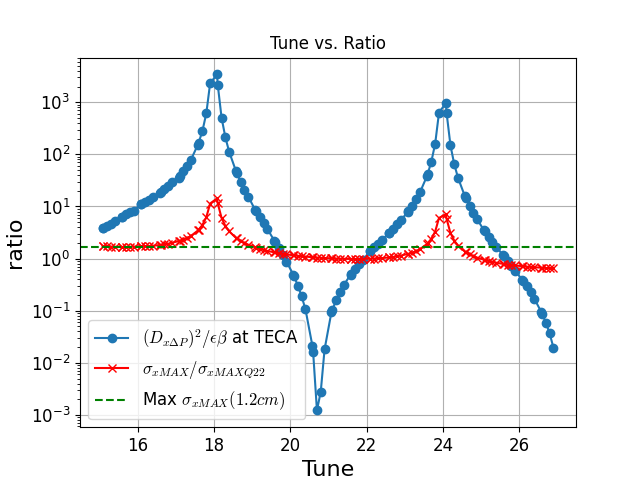

In [132]:
# Calculate the new ratio
#twiss_df['new_ratio'] = (twiss_df['D_xDeltaP']) / twiss_df['EpsilonBeta']

# Plot the data
fig, ax = plt.subplots()
ax.plot(twiss_df['tune'], twiss_df['ratioDxBetaTECA'], marker='o', linestyle='-', label = r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')
ax.plot(twiss_df['tune'], twiss_df['sigma_xMAX'] / sigma_xMAXinit, marker='x', linestyle='-', color='r', label=r'$\sigma_{xMAX} / \sigma_{xMAXQ22}$')
ax.axhline(0.012 / sigma_xMAXinit, color='g', linestyle='--', label=r'Max $ \sigma_{xMAX} (1.2 cm)$')

ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Tune')
ax.set_ylabel(r'ratio')
ax.set_title('Tune vs. Ratio')
ax.grid(True)
plt.show()

# New study regarding the phase advance

In [133]:
twiss_df = twiss_df.drop_duplicates(subset='tune')

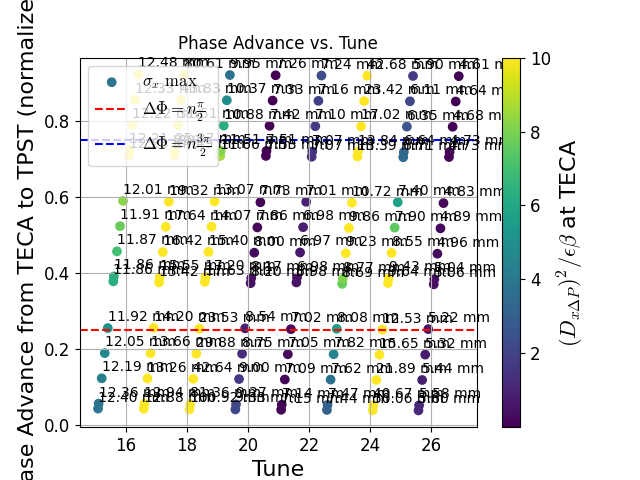

In [134]:
# Plot the fractional part of the phase advance vs. tune
fig, ax = plt.subplots()
sc = ax.scatter(twiss_df['tune'], (twiss_df['delta_mu_xtpst'] % (2 * np.pi)) / (2 * np.pi), c=twiss_df['ratioDxBetaTECA'],  vmax = 10, cmap='viridis', label=r'$\sigma_x \text{ max}$')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')

# Annotate each point with its corresponding sigma_xMAX in mm
for i, row in twiss_df.iterrows():
    sigma_x = row['sigma_xMAX'] * 1000  # Convert to mm
    ax.annotate(f'{sigma_x:.2f} mm', (row['tune'], (row['delta_mu_xtpst'] % (2 * np.pi)) / (2 * np.pi)), textcoords="offset points", xytext=(0,5), ha='left')

ax.set_xlabel('Tune')
ax.set_ylabel('Phase Advance from TECA to TPST (normalized)')
ax.axhline(0.25, color='r', linestyle='--', label=r'$\Delta\Phi = n \frac{\pi}{2}$')
ax.axhline(0.75, color='b', linestyle='--', label=r'$\Delta\Phi = n \frac{3\pi}{2}$')
ax.set_title('Phase Advance vs. Tune')
ax.grid(True)
ax.legend()
plt.show()


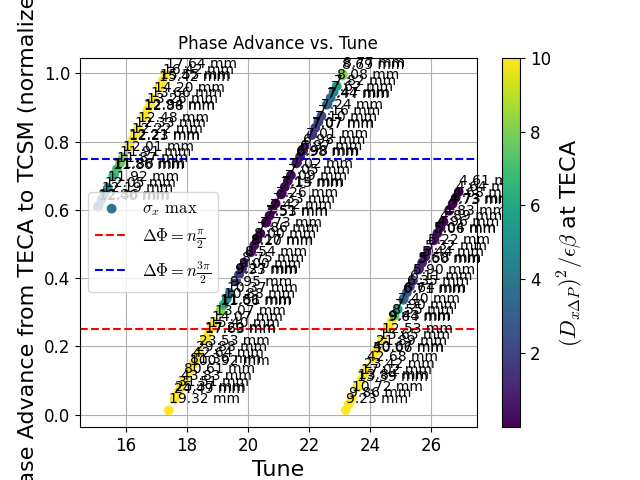

In [135]:
# Plot the fractional part of the phase advance vs. tune
fig, ax = plt.subplots()
sc = ax.scatter(twiss_df['tune'], (twiss_df['delta_mu_x_tcsm'] % (2 * np.pi)) / (2 * np.pi), c=twiss_df['ratioDxBetaTECA'],  vmax = 10,cmap='viridis', label=r'$\sigma_x \text{ max}$')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')

# Annotate each point with its corresponding sigma_xMAX in mm
for i, row in twiss_df.iterrows():
    sigma_x = row['sigma_xMAX'] * 1000  # Convert to mm
    ax.annotate(f'{sigma_x:.2f} mm', (row['tune'], (row['delta_mu_x_tcsm'] % (2 * np.pi)) / (2 * np.pi)), textcoords="offset points", xytext=(0,5), ha='left')

ax.set_xlabel('Tune')
ax.set_ylabel('Phase Advance from TECA to TCSM (normalized)')
ax.axhline(0.25, color='r', linestyle='--', label=r'$\Delta\Phi = n \frac{\pi}{2}$')
ax.axhline(0.75, color='b', linestyle='--', label=r'$\Delta\Phi = n \frac{3\pi}{2}$')
ax.legend()
ax.set_title('Phase Advance vs. Tune')
ax.grid(True)
plt.show()

# Giving a closer look at the TPST

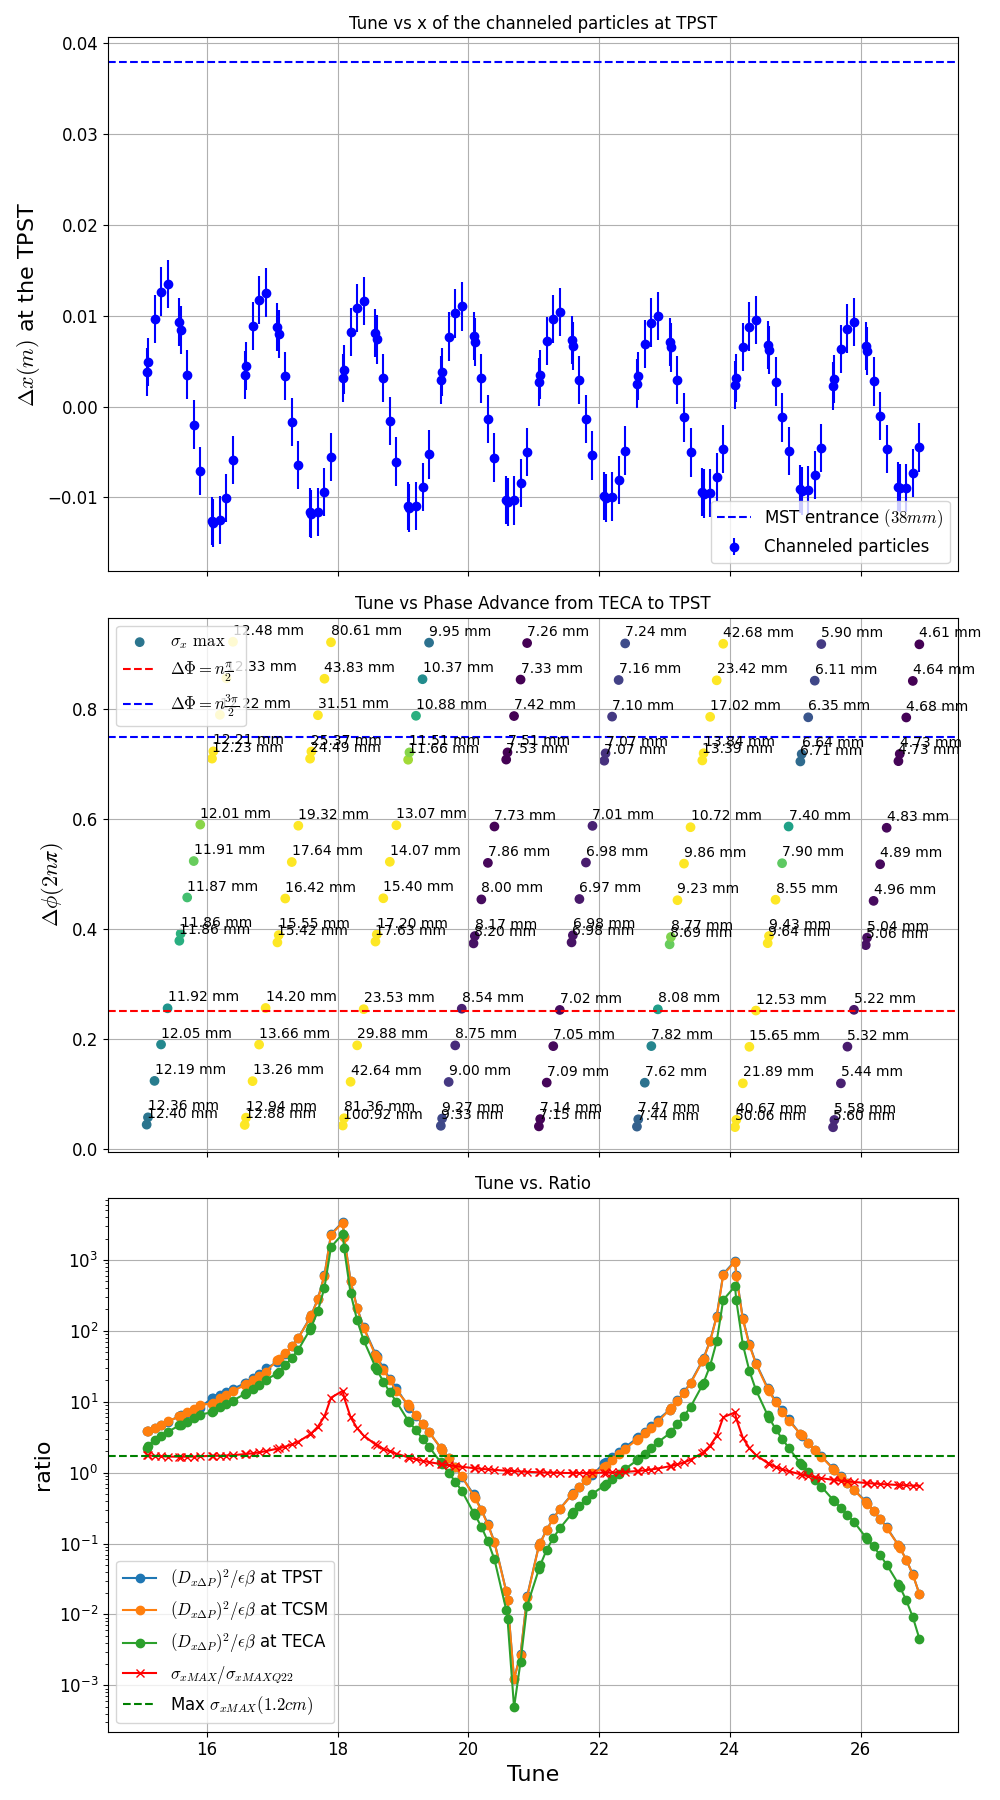

In [138]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(10, 18))

error = np.abs(ErrorEasyDeltaXtpst)
# First subplot
#axs[0].errorbar(twiss_df["tune"], twiss_df["x_channeledTPST_negativeMiddle"], yerr=error, color='b', fmt='o', label="Channeled particles")
#axs[0].errorbar(twiss_df["tune"], twiss_df["x_channeledTPST_negativeMiddle"] - twiss_df["EasyDeltaXtpst"], yerr=error, fmt='o', color='y', label=r"Non-Channeled particles ($x_{ch} - \sqrt{\beta_x \beta_{TPST}} \sin(\delta_{\mu_x}) \theta_{TECA}$)")
axs[0].errorbar(twiss_df["tune"], twiss_df["EasyDeltaXtpst"], yerr=error, color='b', fmt='o', label="Channeled particles")
axs[0].axhline(0.038, color='b', linestyle='--', label=r'MST entrance $ (38 mm )$')
axs[0].set_ylabel(r"$\Delta x (m)$ at the TPST")
axs[0].set_title("Tune vs x of the channeled particles at TPST")
axs[0].legend()
axs[0].grid()

# Second subplot
sc = axs[1].scatter(twiss_df['tune'], (twiss_df['delta_mu_xtpst'] % (2 * np.pi)) / (2 * np.pi), c=twiss_df['ratioDxBetaTECA'], cmap='viridis', vmax = 10, label=r'$\sigma_x \text{ max}$')
#cbar = plt.colorbar(sc, ax=axs[1], pad=0.02)
#cbar.set_label(r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')

# Annotate each point with its corresponding sigma_xMAX in mm
for i, row in twiss_df.iterrows():
    sigma_x = row['sigma_xMAX'] * 1000  # Convert to mm
    axs[1].annotate(f'{sigma_x:.2f} mm', (row['tune'], (row['delta_mu_xtpst'] % (2 * np.pi)) / (2 * np.pi)), textcoords="offset points", xytext=(0, 5), ha='left')

axs[1].set_ylabel(r'$\Delta \phi (2nπ)$')
axs[1].axhline(0.25, color='r', linestyle='--', label=r'$\Delta\Phi = n \frac{\pi}{2}$')
axs[1].axhline(0.75, color='b', linestyle='--', label=r'$\Delta\Phi = n \frac{3\pi}{2}$')
axs[1].set_title('Tune vs Phase Advance from TECA to TPST')
axs[1].grid(True)
axs[1].legend()



# Third subplot
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTECA'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TPST')
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTPST'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TCSM')
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTCSM'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')
axs[2].plot(twiss_df['tune'], twiss_df['sigma_xMAX'] / sigma_xMAXinit, marker='x', linestyle='-', color='r', label=r'$\sigma_{xMAX} / \sigma_{xMAXQ22}$')
axs[2].axhline(0.012 / sigma_xMAXinit, color='g', linestyle='--', label=r'Max $ \sigma_{xMAX} (1.2 cm)$')

axs[2].legend()
axs[2].set_yscale('log')
axs[2].set_xlabel('Tune')
axs[2].set_ylabel(r'ratio')
axs[2].set_title('Tune vs. Ratio')
axs[2].grid(True)

# Ensure the x-axis limits are the same for all subplots
axs[2].set_xlim(axs[0].get_xlim())

plt.tight_layout()
plt.show()





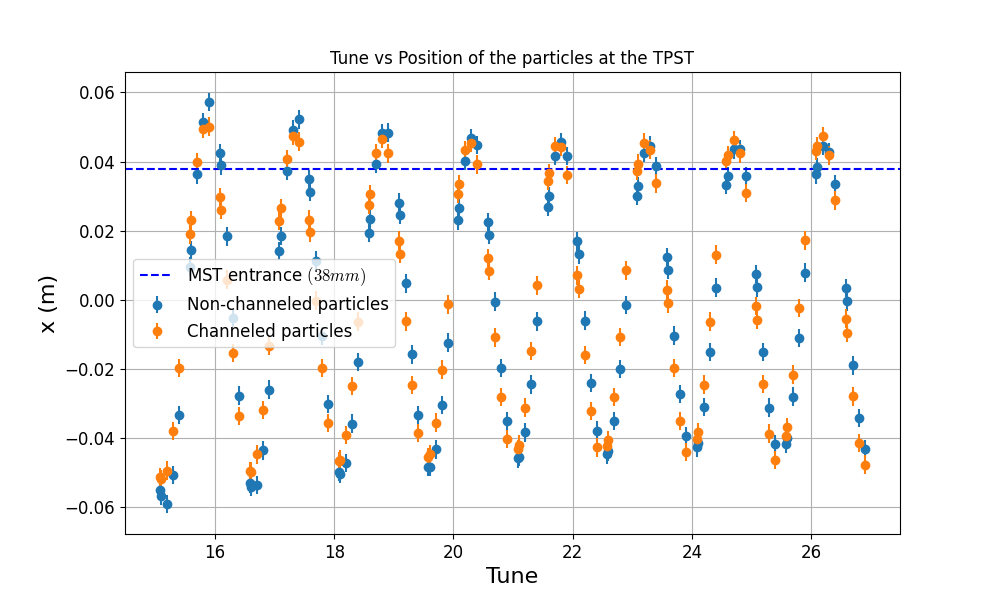

In [140]:
plt.figure(figsize=(10, 6))
error = np.abs(ErrorEasyDeltaXtpst)
plt.errorbar(twiss_df['tune'], twiss_df['x_NONchanneledTPST'] , yerr=error, fmt='o', label='Non-channeled particles')
plt.errorbar(twiss_df['tune'], twiss_df['x_NONchanneledTPST'] +  twiss_df["EasyDeltaXtpst"], yerr=error, fmt='o', label='Channeled particles')

plt.axhline(0.038, color='b', linestyle='--', label=r'MST entrance $ (38 mm )$')
plt.xlabel('Tune')
plt.ylabel('x (m)')
plt.title('Tune vs Position of the particles at the TPST')
plt.legend()
plt.grid(True)
plt.show()